# CATALOG ANALYSIS

In the dataset there are 2 types of contents that the plateform Netflix add to his catalog:
    **Movie** :a long movies that could be lasting many hours.This category represents **69.14%** of **Netflix Catalog**.
    **Tv Show** : series or Tv emission that could have 1 or many seasons .This category represents **30.86%** of **Netflix Catalog**

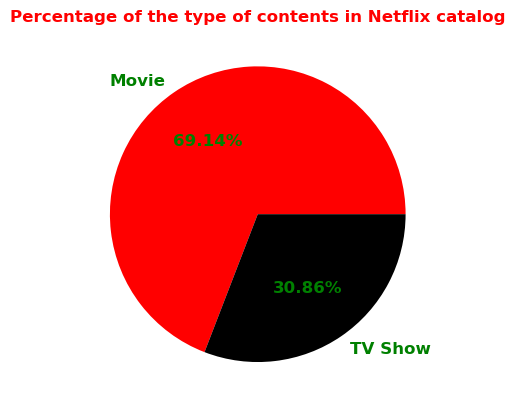

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("../data/netflix_titles_cleaned.csv")
palette=['red','black']
data = df.groupby("type").agg({'show_id':'count'})
data.reset_index(inplace=True)
plt.Figure(figsize=(20,12))
plt.title("Percentage of the type of contents in Netflix catalog",fontdict={'color':'red','weight':'bold'})
plt.pie(data['show_id'],labels=data['type'],autopct='%.2f%%',radius=1,textprops={'fontsize': 12,'weight':'bold','color':'green'},colors=palette)
plt.show()


# COUNTRY SHOOTING

According the dataset the catalog of show in netflix has a lot of country shooting.There are a show that have many countries shooting and there are a show that had shooted in a one country.

The United States,India(exclusivily a movie),United Kingdom engaged the podium whith : more than 2000 show in his catalog 

In [56]:
import pandas as pd

df=pd.read_csv("../data/netflix_titles_cleaned.csv")

countryProportion=df.groupby(["country","type"]).agg({'show_id':"count"})
countryProportion.sort_values('show_id',ascending=False).head(50)


show_id
country                       type            
United States                 Movie       2076
                              TV Show      975
India                         Movie        852
United Kingdom                TV Show      203
                              Movie        193
Japan                         TV Show      155
South Korea                   TV Show      147
Canada                        Movie        118
Spain                         Movie         89
Egypt                         Movie         89
Turkey                        Movie         73
India                         TV Show       71
Philippines                   Movie         70
France                        Movie         69
Japan                         Movie         69
Indonesia                     Movie         68
Taiwan                        TV Show       68
Mexico                        Movie         65
Nigeria                       Movie         62
Canada                        TV Show       59
United Kingdom, United States Movie         52
Hong Kong                     Movie         49
France                        TV Show       46
Brazil                        Movie         46
Spain                         TV Show       45
Australia                     TV Show       44
Germany                       Movie         42
United States, Canada         Movie         38
Australia                     Movie         37
China                         TV Show       36
South Korea                   Movie         36
Thailand                      Movie         35
Mexico                        TV Show       35
Argentina                     Movie         34
United States, United Kingdom Movie         30
Canada, United States         Movie         29
Turkey                        TV Show       27
Italy                         Movie         27
Brazil                        TV Show       26
France, Belgium               Movie         24
Thailand                      TV Show       22
United States, Canada         TV Show       22
China                         Movie         21
South Africa                  Movie         20
Colombia                      TV Show       20
Germany                       TV Show       19
Singapore                     TV Show       17
Argentina                     TV Show       16
Malaysia                      Movie         16
Hong Kong, China              Movie         16

Visualisation of the percentage of country for each show (Tv Show and Movies combined):As we see there are a large domination of the United States with 56.46% of the catalog followed by India with 17.08% and United Kingdom 7.33% 

<Axes: title={'center': 'Country shooting proportion of the netflix catalog(Movies and Tv Shows combined) '}, xlabel='Country Shooting', ylabel='Show Number'>

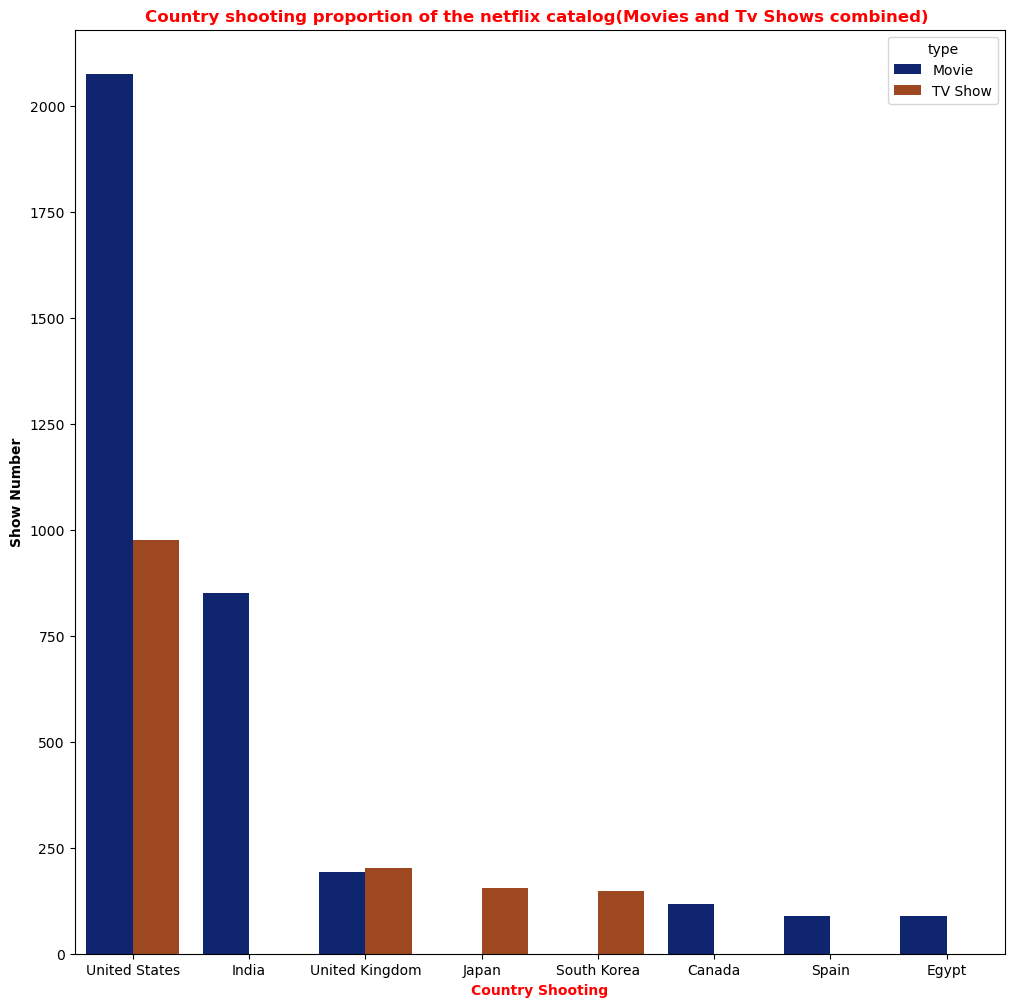

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/netflix_titles_cleaned.csv")
allCountryProportion= df.groupby(['country','type']).agg({'show_id':'count'})
allCountryProportion.reset_index(inplace=True)
allCountryProportion.sort_values(by='show_id',ascending=False)
data=allCountryProportion.sort_values(by='show_id',ascending=False).head(10)
plt.figure(figsize=(12,12))
plt.title("Country shooting proportion of the netflix catalog(Movies and Tv Shows combined) ",fontdict={'color':'red','weight':'bold'})
plt.xlabel("Country Shooting",color="red",weight='bold')
plt.ylabel("Show Number",color="black",weight='bold')
sns.barplot(data=data,x=data['country'],y=data['show_id'],palette='dark',hue='type')



# CATALOG EVOLUTION 

The catalog starts slowly to appear on September 2016,reachs his first pick in 2018-2019
Netflix had his pick during the covid-19 pandemy with 212 show added in 3 months only

<Axes: title={'center': 'Evolution of the Netflix Catalog '}, xlabel='Periode', ylabel='Catalog number'>

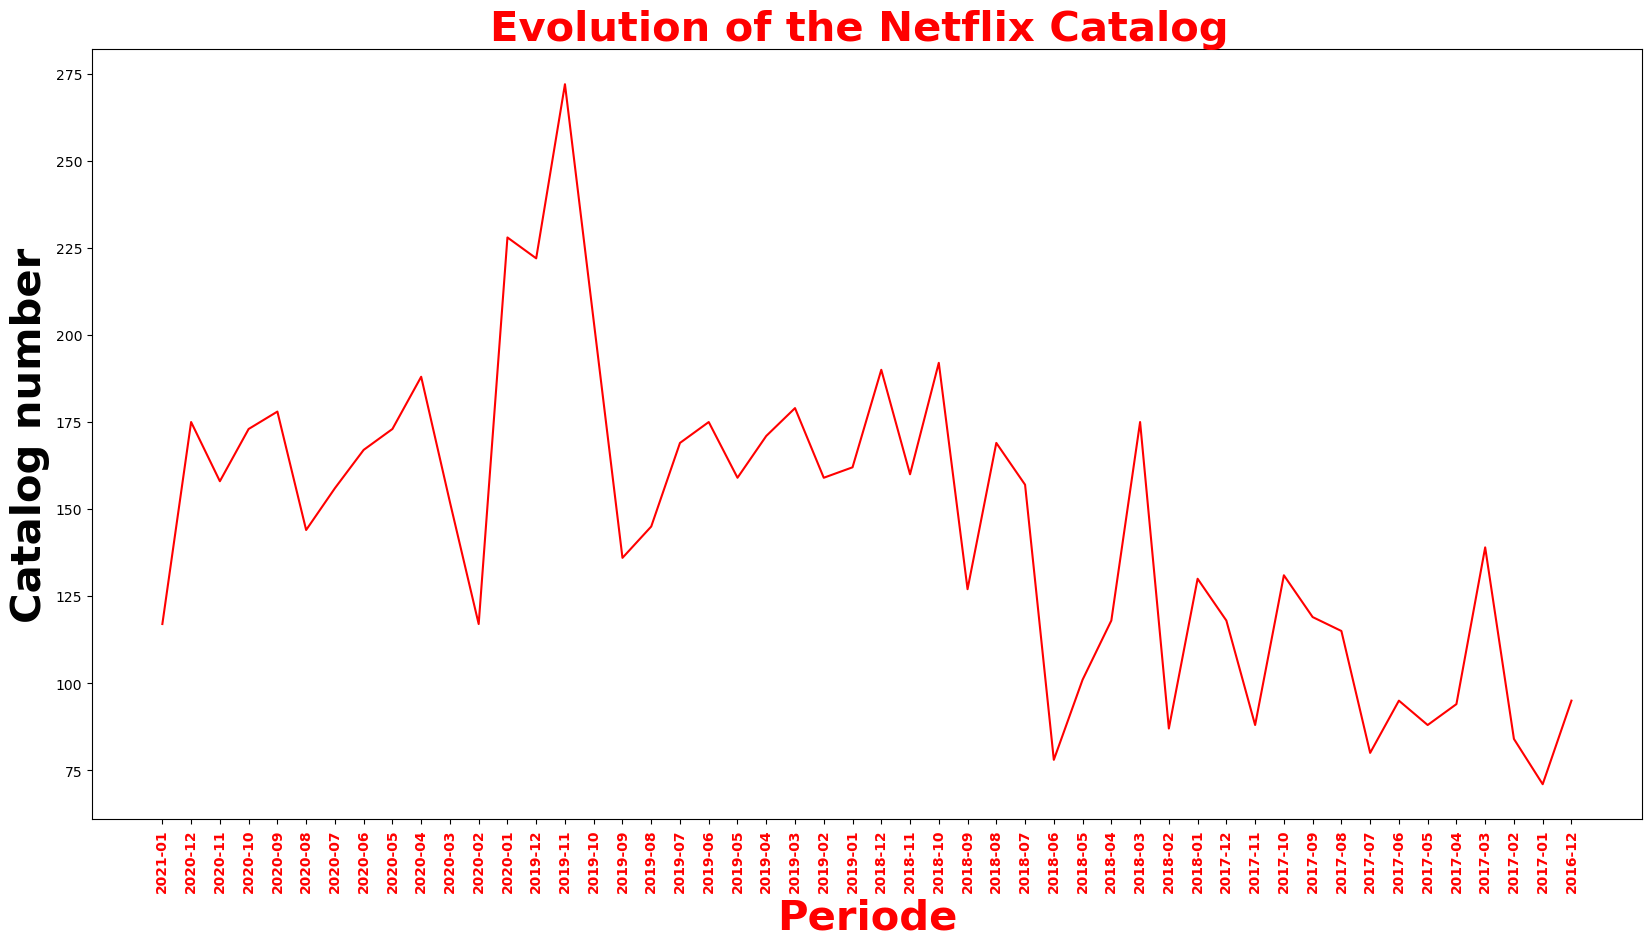

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/netflix_titles_cleaned.csv")

countryProportion=df.groupby("date_added").agg({'show_id':"count"})
countryProportion.sort_values('show_id',ascending=False)
countryProportion.reset_index(inplace=True)
countryProportion['date_added']=pd.to_datetime(countryProportion['date_added'], dayfirst=False)
countryProportion['periode'] = countryProportion['date_added'].dt.to_period("M")
data_grouped = countryProportion.groupby('periode').agg({'show_id': 'count'})
data_grouped.reset_index(inplace=True)
data_grouped = countryProportion.groupby('periode').agg({'show_id': 'sum'}).reset_index()
data_grouped = data_grouped.sort_values(by='periode',ascending=False)
data_grouped['periode']=data_grouped['periode'].astype(str)
data=data_grouped.head(50)
plt.figure(figsize=(20,10))
plt.title("Evolution of the Netflix Catalog ",size=30,fontdict={'color':'red','weight':'bold'})
plt.xticks(rotation=90,weight='bold',color='red')
plt.xlabel("Periode",color="red",weight='bold',size=30)
plt.ylabel("Catalog number",color="black",weight='bold',size=30)
sns.lineplot(data=data,x=data['periode'],y=data['show_id'],color='red')








# MOVIE RELEASING_YEAR

During 50 last year 2018 is the most productive year in Holywood because there was 1120 show came out.
in 2021 there was an incredible downfall because of pandemy:only 31 show



<Axes: title={'center': 'Evolution of Show Released per Year '}, xlabel='Year', ylabel='Show Released'>

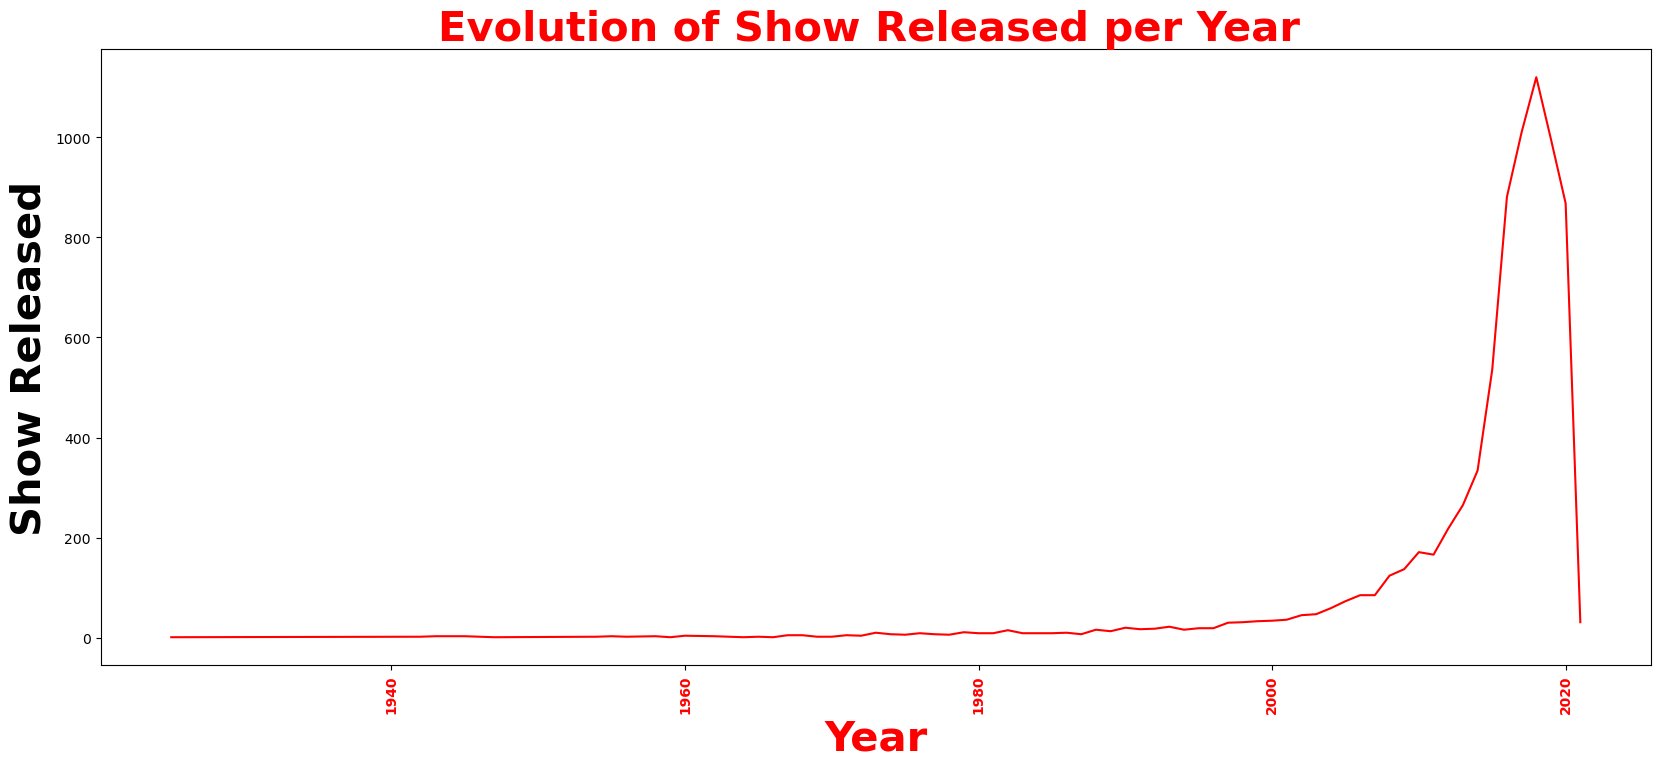

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/netflix_titles_cleaned.csv")

countryProportion=df.groupby("release_year").agg({'show_id':"count"})
countryProportion.sort_values('release_year',ascending=False)
countryProportion.reset_index(inplace=True)
plt.figure(figsize=(20,8))
plt.title("Evolution of Show Released per Year ",size=30,fontdict={'color':'red','weight':'bold'})
plt.xticks(rotation=90,weight='bold',color='red')
plt.xlabel("Year",color="red",weight='bold',size=30)
plt.ylabel("Show Released",color="black",weight='bold',size=30)
sns.lineplot(data=countryProportion,x=countryProportion['release_year'],y=countryProportion['show_id'],color='red')


# CONTENTS DURATION

The catalog of netflix has on average 2 seasons for the Tv Show and the movies last on average 100 minutes

In [63]:
import pandas as pd
import matplotlib as plt

df=pd.read_csv("../data/netflix_titles_cleaned.csv")


data = df.groupby("type").agg({'duration':'mean'})
data

,duration
type,
Movie,99.330417
TV Show,1.761468


# CATEGORY 

Documentary,Stand_up comedy,Dramas and International movies dominate the standing 

/tmp/ipykernel_12835/3517040360.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datas,x=datas['listed_in'],y=datas['show_id'],palette='dark')


<Axes: title={'center': "Shows' category proportion"}, xlabel='Category', ylabel='Show Number'>

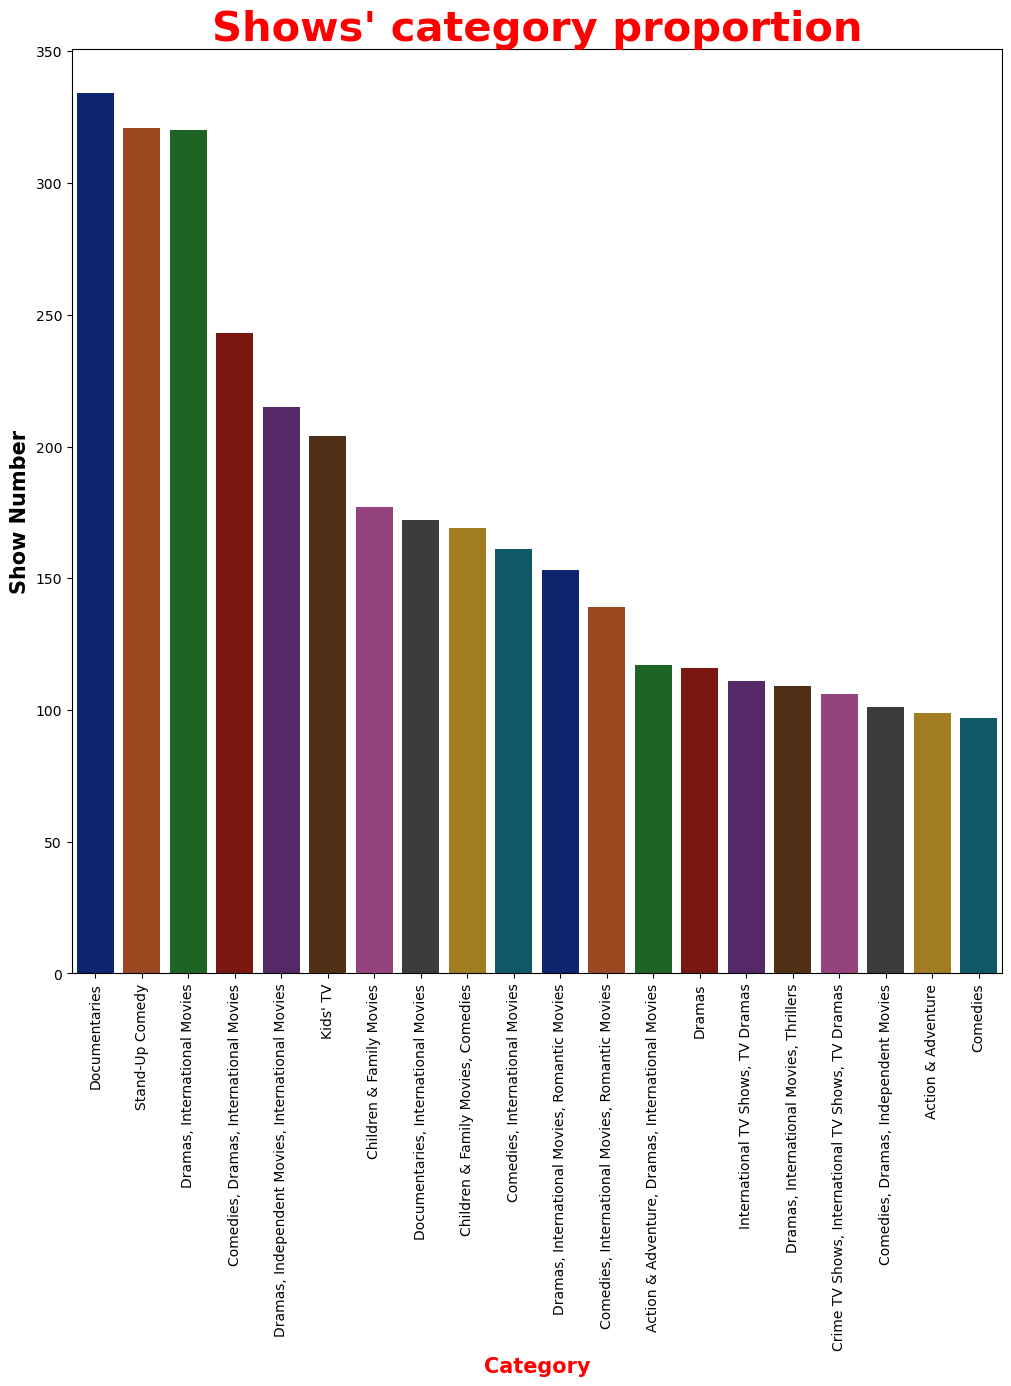

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df=pd.read_csv("../data/netflix_titles_cleaned.csv")


data = df.groupby("listed_in").agg({'show_id':'count'})
data.reset_index(inplace=True)
data.sort_values(by="show_id",ascending=False,inplace=True)
datas=data.head(20)
plt.figure(figsize=(12,12))
plt.title("Shows' category proportion",fontdict={'color':'red','weight':'bold'},size=30)
plt.xticks(rotation=90)
plt.xlabel("Category",color="red",weight='bold',size=15)
plt.ylabel("Show Number",color="black",weight='bold',size=15)
sns.barplot(data=datas,x=datas['listed_in'],y=datas['show_id'],palette='dark')


# AVERAGE DURATION PER CATEGORY OF SHOW



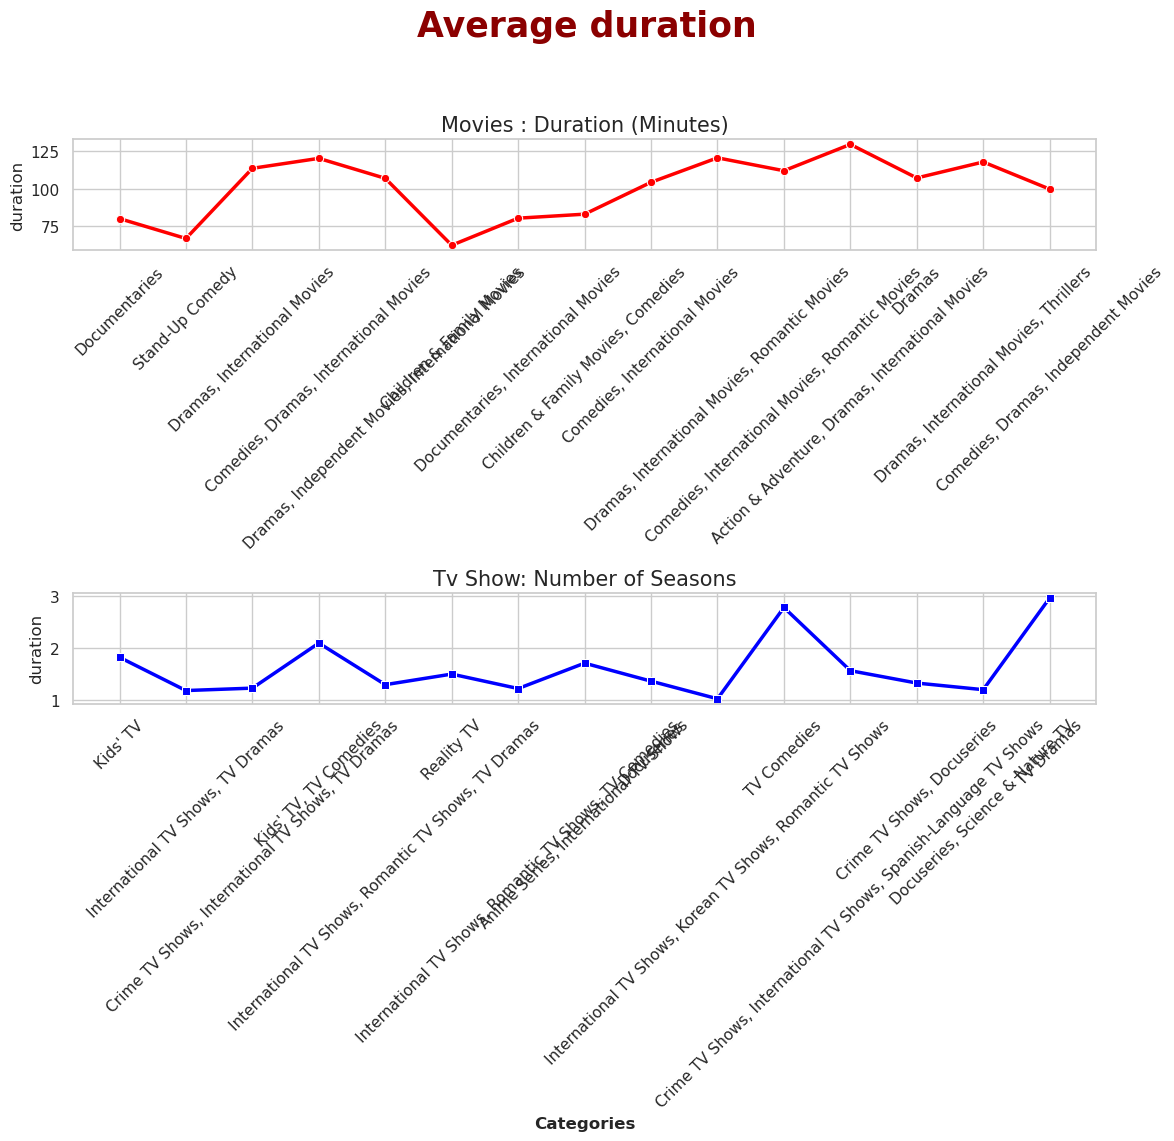

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/netflix_titles_cleaned.csv")


data = df.groupby(["listed_in",'type']).agg({'show_id':'count','duration':'mean'}).reset_index()
data.sort_values(by="show_id", ascending=False, inplace=True)


movies = data[data["type"] == "Movie"].head(15)
tv_shows = data[data["type"] == "TV Show"].head(15)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
fig.suptitle("Average duration", size=25, color='darkred', weight='bold')


sns.lineplot(data=movies, x='listed_in', y='duration', ax=ax1, marker='o', color='red', linewidth=2.5)
ax1.set_title("Movies : Duration (Minutes)", fontsize=15)
ax1.set_xlabel("") 
ax1.tick_params(axis='x', rotation=45)

# --- GRAPHIQUE 2 : TV SHOWS (avec Seaborn) ---
sns.lineplot(data=tv_shows, x='listed_in', y='duration', ax=ax2, marker='s', color='blue', linewidth=2.5)
ax2.set_title("Tv Show: Number of Seasons", fontsize=15)
ax2.set_xlabel("Categories", fontsize=12, weight='bold')
ax2.tick_params(axis='x', rotation=45)

# Ajustement automatique pour que rien ne se chevauche
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
